<a href="https://colab.research.google.com/github/Kadergueli/conflict-risk-analysis-chad/blob/main/01_data_explorationipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')
#
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/ACLED_CHAD_RESEARCH/data/acled_chad.csv')
print(df.head())
#first exploration
df.info()
df.isnull().sum()
df['EVENT_TYPE'].value_counts()

Mounted at /content/drive
   GWNO EVENT_ID_CNTY  EVENT_ID_NO_CNTY  EVENT_DATE  YEAR  TIME_PRECISION  \
0   483          3CHA             12256  15/02/1997  1997               3   
1   483          1CHA             12254  15/02/1997  1997               3   
2   483          2CHA             12255  15/02/1997  1997               3   
3   483          4CHA             12257  15/07/1997  1997               3   
4   483          5CHA             12258  24/07/1997  1997               2   

                      EVENT_TYPE                                     ACTOR1  \
0     Violence against civilians                           Civilians (Chad)   
1     Violence against civilians  FARF: Armed Forces for a Federal Republic   
2     Violence against civilians  FARF: Armed Forces for a Federal Republic   
3  Battle-No change of territory          FDR: Democratic Front for Renewal   
4     Violence against civilians            Unidentified Armed Group (Chad)   

                  ALLY_ACTOR_1  INTE

,count
EVENT_TYPE,
Battle-No change of territory,243
Violence against civilians,181
Battle-Non-state actor overtakes territory,36
Riots/Protests,30
Remote violence,24
Non-violent activity by a conflict actor,21
Battle-Government regains territory,18
Non-violent transfer of territory,5


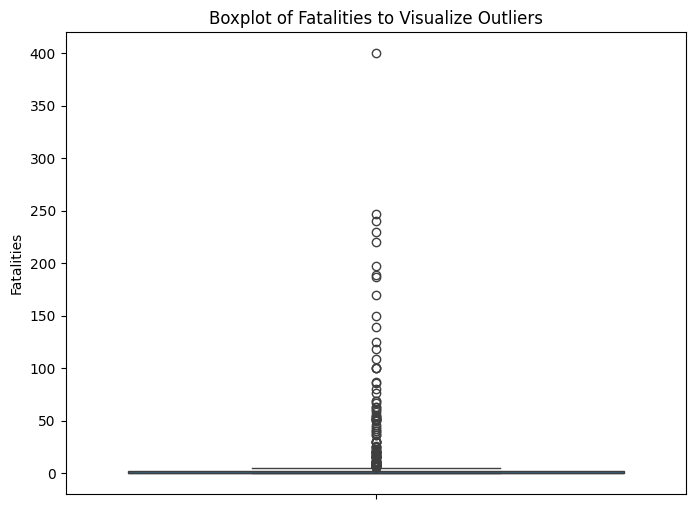

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(y=df['FATALITIES'])
plt.title('Boxplot of Fatalities to Visualize Outliers')
plt.ylabel('Fatalities')
plt.show()

In [3]:
Q1 = df['FATALITIES'].quantile(0.25)
Q3 = df['FATALITIES'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['FATALITIES'] < lower_bound) | (df['FATALITIES'] > upper_bound)]

print("Outliers in 'FATALITIES' column:")
print(outliers)

Outliers in 'FATALITIES' column:
     GWNO EVENT_ID_CNTY  EVENT_ID_NO_CNTY  EVENT_DATE  YEAR  TIME_PRECISION  \
3     483          4CHA             12257  15/07/1997  1997               3   
8     483         10CHA             12263  30/10/1997  1997               1   
10    483         11CHA             12264  31/10/1997  1997               1   
12    483         13CHA             12266  29/11/1997  1997               1   
14    483         15CHA             12268  05/12/1997  1997               1   
..    ...           ...               ...         ...   ...             ...   
505   483        506CHA             12759  24/04/2010  2010               1   
514   483        515CHA             12768  17/09/2011  2011               1   
539   483        541CHA             12794  10/04/2014  2014               1   
547   483        548CHA             12801  04/08/2014  2014               1   
548   483        549CHA             12802  09/08/2014  2014               1   

                  

In [4]:
df_outliers = outliers.copy()
print("New dataset containing only outliers:")
display(df_outliers.head())

New dataset containing only outliers:


,GWNO,EVENT_ID_CNTY,EVENT_ID_NO_CNTY,EVENT_DATE,YEAR,TIME_PRECISION,EVENT_TYPE,ACTOR1,ALLY_ACTOR_1,INTER1,...,ADMIN1,ADMIN2,ADMIN3,LOCATION,LATITUDE,LONGITUDE,GEO_PRECIS,SOURCE,NOTES,FATALITIES
3,483,4CHA,12257,15/07/1997,1997,3,Battle-No change of territory,FDR: Democratic Front for Renewal,NaN,2,...,Guéra,Guéra,Mousmare,Bose,"11,07000","17,83000",2,Africa Research Bulletin,Battle from 10/19-10/20. Fatalities: 40 soldie...,40
8,483,10CHA,12263,30/10/1997,1997,1,Violence against civilians,FARF: Armed Forces for a Federal Republic,NaN,2,...,Logone Oriental,Nya Pendé,Mbaikoro,Moundou,"8,56670","16,08330",2,Africa Research Bulletin,FARF killed 52 civilians during a battle with ...,52
10,483,11CHA,12264,31/10/1997,1997,1,Battle-No change of territory,FARF: Armed Forces for a Federal Republic,NaN,2,...,Logone Oriental,Nya Pendé,Mbaikoro,Moundou,"8,56670","16,08330",1,Reuters,NaN,58
12,483,13CHA,12266,29/11/1997,1997,1,Violence against civilians,FARF: Armed Forces for a Federal Republic,NaN,2,...,Logone Oriental,Nya Pendé,Mbaikoro,Moundou,"8,56670","16,08330",2,Africa Research Bulletin,FARF killed between 7-40 civilians,30
14,483,15CHA,12268,05/12/1997,1997,1,Violence against civilians,FARF: Armed Forces for a Federal Republic,NaN,2,...,Moyen-Chari,Barh K÷h,Sarh,Sarh,"9,14000","18,39000",1,Reuters,FARF raided market and killed traders,23
